In [1]:
import torch
from sorl.gat_sim import GAT, GATConfig, BOS_TOKEN_ID
torch.set_float32_matmul_precision('high')  # Enable TF32 for ~2x speedup
# For fast training, set 'BOS_TOKEN_ID' to 15 in 'sorl/gat_sim.py' 

gat_config = GATConfig(
    vocab_sizes=[BOS_TOKEN_ID+1, 6],  # 6 abstract tokens
    n_layer=4,
    n_head=4,
    n_embd=128,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

model = GAT(gat_config)
# model = model.to("cuda")
# model = torch.compile(model)

In [13]:
# Random-initialize with mode: (a). wte & lm_head for abs tokens (b). wte & lm_head (c). all parameters
init_range = 0.01

def reinit_model(model, mode: int = 0, init_range: float = 0.01):
    def _reset_slice(tensor, slc):
        tensor.detach()[slc].uniform_(-init_range, init_range)

    with torch.no_grad():
        if mode == 0:  # abstract only
            slc = slice(model.vocab_sizes[0].item(), None)
            _reset_slice(model.transformer.wte.weight, slc)
            _reset_slice(model.lm_head.weight, slc)
        elif mode == 1:  # embedding + head
            model.transformer.wte.weight.detach().uniform_(-init_range, init_range)
            model.lm_head.weight.detach().uniform_(-init_range, init_range)
        elif mode == 2:  # full model
            for param in model.parameters():
                param.detach().uniform_(-init_range, init_range)
        else:
            raise ValueError(f"Unknown reinit mode {mode}")

reinit_model(model, mode=1)

In [14]:
model

GAT(
  (transformer): ModuleDict(
    (wte): Embedding(27, 128)
    (h): ModuleList(
      (0-3): 4 x Block(
        (attn): CausalSelfAttention(
          (c_q): CastedLinear(in_features=128, out_features=128, bias=False)
          (c_k): CastedLinear(in_features=128, out_features=128, bias=False)
          (c_v): CastedLinear(in_features=128, out_features=128, bias=False)
          (rotary): Rotary()
          (c_proj): CastedLinear(in_features=128, out_features=128, bias=False)
        )
        (mlp): MLP(
          (c_fc): CastedLinear(in_features=128, out_features=512, bias=False)
          (c_proj): CastedLinear(in_features=512, out_features=128, bias=False)
        )
      )
    )
  )
  (lm_head): CastedLinear(in_features=128, out_features=27, bias=False)
)

In [2]:
# ---- Copy & Paste Data Loader ----
from data.copy_paste import CopyPasteDataLoader

seq_len = 16
loader = CopyPasteDataLoader(vocab_size=16, max_token=10, seq_len=seq_len, device='cpu')
tokens, loss_mask = loader.get_batch(2)

(A). select one SoRL: 
$$
\begin{align*}
&\mathcal{L}(s, a) := \hat{p}_{\theta}(s | a) + \alpha \cdot \hat{p}_{\theta}(a | s) \\
&a_{i} \sim \hat{p}_{\theta}(a | s), \quad a^{*} = \arg \max_{a_{1:n}} \hat{p}_{\theta}(s | a)  \\
&\theta = \theta - {d\mathcal{L}(s, a^{*})}/{d \theta} \\
\end{align*}
$$
exploration (\alpha = -0.1) exploitation (\alpha=0.1)

In [3]:
from sorl.neo_utils import sorl_search, sorl_search_v2, compute_loss, sorl_evaluate, compute_vocab_utilization_rate
from sorl.gapt import GatedPhaseTransition
import copy
from collections import defaultdict

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)

batch_size = 16
memory_span = 2 * seq_len + 2
attn_blocksize = 1792
alpha_sel = 0.0
alpha_loss = 0.1 # exploitation
sel_mode = "abs_ppt"
n = 2
min_temperature = 0.0
max_temperature = 5
temperatures = torch.tensor([min_temperature, max_temperature], device=model.device)
n_eval = 4 
temperatures_eval = torch.tensor([min_temperature, max_temperature, max_temperature, max_temperature], device=model.device)
K = 4
max_iterations = 2
num_steps = 5
gapt = GatedPhaseTransition()

record = defaultdict(list)
vocab_util = 1.0
for step in range(num_steps): 
    # if vocab_util < 0.5:
    #     alpha_loss = - 0.1 # encourage vocab utilization
    # else: 
    #     alpha_loss = 0.1 # encourage search_adv

    memory_span = 1792
 
    optimizer.zero_grad()

    tokens, _ = loader.get_batch(batch_size)

    # --- mixture of SoRL selection & deep supervision (avg. loss per iteration) ---
    with torch.no_grad(): 
        search_tokens, search_ppt, search_adv = sorl_search_v2(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures,
                                                               truncate_seq_len=False, alpha_select=alpha_sel, select_mode=sel_mode)
        print(f" - training search_adv: {search_adv.item() * 100:.2f}%")
    # --- compute loss ---
    traj_loss, abs_loss = compute_loss(search_tokens, model, memory_span=memory_span, attn_blocksize=attn_blocksize)    
                                       
    # loss = gapt.step(traj_loss, alpha_loss * abs_loss, verbose=True)
    loss = traj_loss + alpha_loss * abs_loss

    # --- optimize --- 
    loss.backward() 
    optimizer.step()

    # break

    if step % 2 == 0: 
        with torch.no_grad(): 
            temperatures_eval = torch.tensor([0.0, max_temperature, max_temperature, max_temperature], device=model.device)
            val_tokens, val_adv, traj_loss, abs_loss = sorl_evaluate(tokens, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                     truncate_seq_len=False)
            traj_loss, abs_loss = compute_loss(val_tokens, model, memory_span=memory_span, attn_blocksize=attn_blocksize)
            vocab_util = compute_vocab_utilization_rate(val_tokens, model)
            record['vocab_util'].append(vocab_util * 100)
            record['search_adv'].append(val_adv.item() * 100)
            record['abs_loss'].append(abs_loss.item())
            record['alpha_loss'].append(alpha_loss)
        print(f"validation step {step} | traj_loss: {traj_loss.item():.2f} | abs_loss: {abs_loss.item():.2f} | search adv: {val_adv.item() * 100:.2f}% | vocab util: {vocab_util * 100:.2f}% | alpha_loss: {alpha_loss:.2f}")

 - training search_adv: 0.00%
validation step 0 | traj_loss: 3.26 | abs_loss: 3.27 | search adv: 0.02% | vocab util: 83.33% | alpha_loss: 0.10
 - training search_adv: 0.07%
 - training search_adv: 0.09%
validation step 2 | traj_loss: 3.13 | abs_loss: 3.26 | search adv: -0.02% | vocab util: 83.33% | alpha_loss: 0.10
 - training search_adv: 0.15%
 - training search_adv: 0.12%
validation step 4 | traj_loss: 2.90 | abs_loss: 3.36 | search adv: 0.07% | vocab util: 33.33% | alpha_loss: 0.10


In [4]:
# utility based resampling
# search_tokens, search_ppt, search_adv = sorl_search_v2(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures,
                                                            #    truncate_seq_len=False, alpha_select=alpha_sel, select_mode=sel_mode)
from sorl.neo_utils import sorl_search
search_tokens, search_ppt, search_adv = sorl_search(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures,
                                                               truncate_seq_len=False, alpha_select=alpha_sel, select_mode=sel_mode)

(B). Exploration with SGPO, Exploitation with Offline Distillation

- SGPO
$$
\begin{align*}
&\mathcal{L}_{SGPO}(s, a_{i}) := \frac{\hat{p}_{\theta}(s | a_{i}) - \text{mean}(\hat{p}_{\theta}(s | a_{1:n}))}{\text{std}(\hat{p}_{\theta}(s | a_{1:n}))}\hat{p}_{\theta}(s | a) + \alpha \cdot \hat{p}_{\theta}(a | s) \\
&a_{i} \sim \hat{p}_{\theta}(a | s) \\
&\theta = \theta - {d\mathcal{L}_{SGPO}(s, a_{i})}/{d \theta} \quad \text{for } i \in \{1,2,\dots, n\}\\
\end{align*}
$$

- Offline Distillation (Question: why not using SGPO loss?)
$$
\begin{align*}
&a^{*} = \argmax_{a} \hat{p}_{\theta}(a | s) \\
&\theta = \theta - \frac{d \mathcal{L}(s, a)}{d \theta} \\
&\mathcal{L}(s, a) = \hat{p}_{\theta}(s | a) + \alpha \cdot \hat{p}_{\theta}(a | s)
\end{align*}
$$

- Switch logic: 'vocab util' target

In [5]:
# --- Exploration & Exploitation ----
# Exploitation phase (Offline Distillation) :: n = 1, t = 0.0, alpha_loss = 0.1, 'sorl_search_v3'
# Exploration phase (SGPO) :: n = 2, t = [0.0, 5.0], alpha_loss = 0.1, 'sorl_search_v3'
# --- Essentially we are eliminating the 'select & stitch' mechanism in single-select SoRL here ---- 


from sorl.neo_utils import sorl_search_v3, sorl_search_v2, compute_sgpo_loss, sorl_evaluate, compute_vocab_utilization_rate, compute_loss
from sorl.gapt import GatedPhaseTransition
import copy
from collections import defaultdict

# ----- Reference model (EMA) ---- 
ref_model = copy.deepcopy(model)
ref_model.eval()
ref_model.requires_grad_(False)

# ------ SGPO for emerging abstraction structure -------
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)

batch_size = 16
memory_span = 2 * seq_len + 2
attn_blocksize = 1792
alpha_loss = 0.1
n = 2
min_temperature = 0.0
max_temperature = 5
temperatures = torch.tensor([min_temperature, max_temperature], device=model.device)
n_eval = 4 
temperatures_eval = torch.tensor([min_temperature, max_temperature, max_temperature, max_temperature], device=model.device)
K = 4
max_iterations = 2
num_steps = 500
gapt = GatedPhaseTransition()
phase = "exploration"

record = defaultdict(list)
vocab_util = 1.0
for step in range(num_steps): 

    if step >= 300 and vocab_util > 0.5: # one-time switch to exploitation phase
        if phase == "exploration":  # load reference model at the start of exploitation phase
            print(f" - initializing reference model -")
            ref_model.load_state_dict(model.state_dict())
        n, phase = 1, "exploitation"
        temperatures = torch.tensor([0.0], device=model.device)

    memory_span = 1792
 
    optimizer.zero_grad()

    tokens, _ = loader.get_batch(batch_size)

    # --- mixture of SoRL selection & deep supervision (avg. loss per iteration) ---
    with torch.no_grad(): 
        search_tokens, search_ppt, search_adv = sorl_search_v3(tokens, 
                                                            model, # model if phase == "exploration" else ref_model,
                                                            n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures,
                                                            truncate_seq_len=False)
        
    if phase == "exploration":
        traj_loss, abs_loss = compute_sgpo_loss(search_tokens, search_adv, model, memory_span, attn_blocksize)    
    else: 
        traj_loss, abs_loss = compute_loss(search_tokens, model, memory_span, attn_blocksize)
                              
    # loss = gapt.step(traj_loss, alpha_loss * abs_loss, verbose=True)
    loss = traj_loss + alpha_loss * abs_loss

    # --- optimize --- 
    loss.backward() 
    optimizer.step()

    if step % 2 == 0: 
        with torch.no_grad(): 
            temperatures_eval = torch.tensor([0.0, max_temperature, max_temperature, max_temperature], device=model.device)
            val_tokens, val_adv, traj_loss, abs_loss = sorl_evaluate(tokens, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                     truncate_seq_len=False)
            vocab_util = compute_vocab_utilization_rate(val_tokens, model)
            record['vocab_util'].append(vocab_util * 100)
            record['search_adv'].append(val_adv.item() * 100)
            record['abs_loss'].append(abs_loss.item())
            record['phase'].append(phase)
        print(f"validation step {step} | traj_loss: {traj_loss.item():.2f} | abs_loss: {abs_loss.item():.2f} | search adv: {val_adv.item() * 100:.2f}% | vocab util: {vocab_util * 100:.2f}% | phase: {phase}")

validation step 0 | traj_loss: 1.15 | abs_loss: 1.27 | search adv: 1.52% | vocab util: 33.33% | phase: exploration
validation step 2 | traj_loss: 1.17 | abs_loss: 1.61 | search adv: 0.19% | vocab util: 33.33% | phase: exploration
validation step 4 | traj_loss: 1.14 | abs_loss: 1.82 | search adv: -0.33% | vocab util: 33.33% | phase: exploration
validation step 6 | traj_loss: 1.15 | abs_loss: 2.92 | search adv: 0.14% | vocab util: 33.33% | phase: exploration
validation step 8 | traj_loss: 1.14 | abs_loss: 3.77 | search adv: -1.74% | vocab util: 50.00% | phase: exploration
validation step 10 | traj_loss: 1.14 | abs_loss: 3.25 | search adv: 0.15% | vocab util: 50.00% | phase: exploration
validation step 12 | traj_loss: 1.14 | abs_loss: 3.60 | search adv: 0.66% | vocab util: 50.00% | phase: exploration
validation step 14 | traj_loss: 1.13 | abs_loss: 4.25 | search adv: 1.14% | vocab util: 33.33% | phase: exploration
validation step 16 | traj_loss: 1.14 | abs_loss: 3.80 | search adv: 1.42% |

KeyboardInterrupt: 

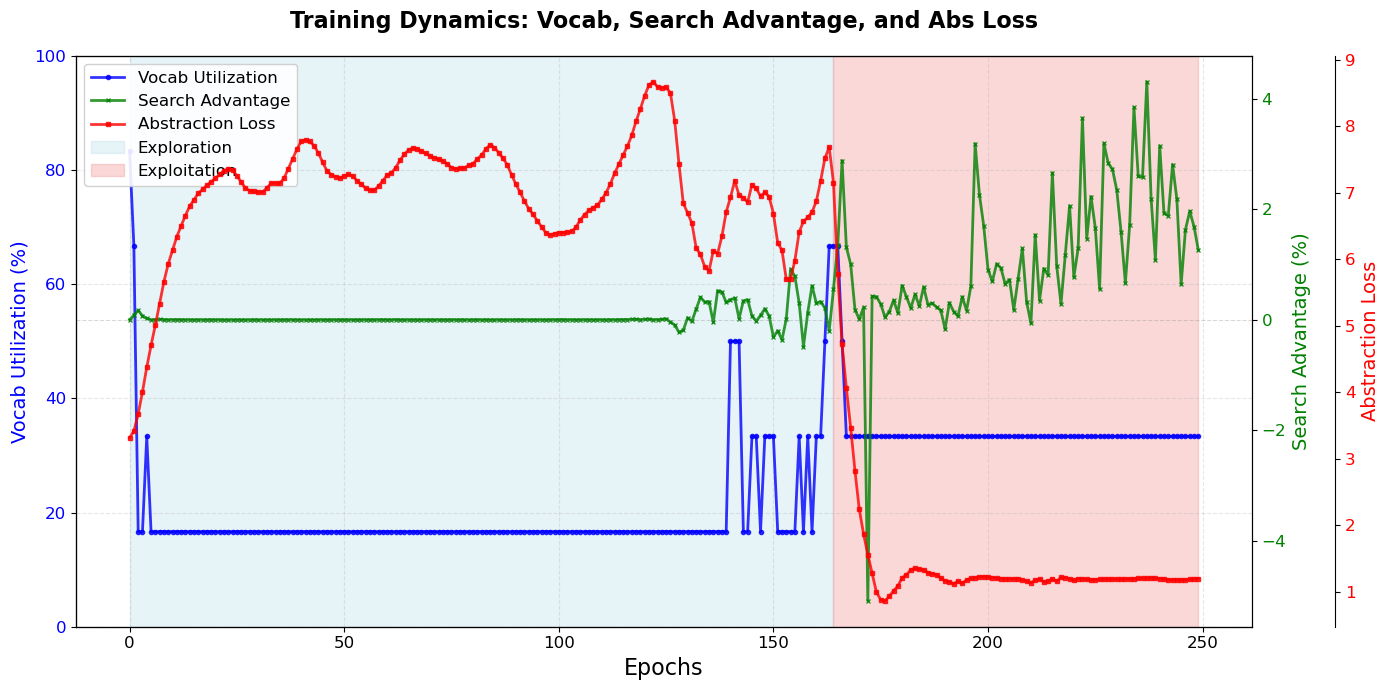

In [4]:
from sorl.stat import plot_training_metrics_combined
plot_training_metrics_combined(record)

(C). Simplified Group Preference Optimization (SGPO)
$$
\begin{align*}
&\mathcal{L}_{SGPO}(s, a_{i}) := \frac{\hat{p}_{\theta}(s | a_{i}) - \text{mean}(\hat{p}_{\theta}(s | a_{1:n}))}{\text{std}(\hat{p}_{\theta}(s | a_{1:n}))}\hat{p}_{\theta}(s | a) + \alpha \cdot \hat{p}_{\theta}(a | s) \\
&a_{i} \sim \hat{p}_{\theta}(a | s) \\
&\theta = \theta - {d\mathcal{L}_{SGPO}(s, a_{i})}/{d \theta} \quad \text{for } i \in \{1,2,\dots, n\}\\
\end{align*}
$$
Leads to emergent abstraction structure (unstable)

In [ ]:
# model : save
torch.save(model.state_dict(), 'model_weights.pt')
# model : load
model.load_state_dict(torch.load('model_weights.pt', map_location='cuda'))

GAT(
  (transformer): ModuleDict(
    (wte): Embedding(27, 128)
    (h): ModuleList(
      (0-3): 4 x Block(
        (attn): CausalSelfAttention(
          (c_q): CastedLinear(in_features=128, out_features=128, bias=False)
          (c_k): CastedLinear(in_features=128, out_features=128, bias=False)
          (c_v): CastedLinear(in_features=128, out_features=128, bias=False)
          (rotary): Rotary()
          (c_proj): CastedLinear(in_features=128, out_features=128, bias=False)
        )
        (mlp): MLP(
          (c_fc): CastedLinear(in_features=128, out_features=512, bias=False)
          (c_proj): CastedLinear(in_features=512, out_features=128, bias=False)
        )
      )
    )
  )
  (lm_head): CastedLinear(in_features=128, out_features=27, bias=False)
)

In [3]:
from sorl.neo_utils import sorl_search_v3, compute_sgpo_loss, sorl_evaluate, compute_vocab_utilization_rate, compute_loss
from sorl.gapt import GatedPhaseTransition
import copy
from collections import defaultdict

# ------ SGPO for emerging abstraction structure -------
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)

batch_size = 16
memory_span = 2 * seq_len + 2
attn_blocksize = 1792
alpha_loss = 0.1
n = 2
min_temperature = 0.0
max_temperature = 5
temperatures = torch.tensor([min_temperature, max_temperature], device=model.device)
n_eval = 4 
temperatures_eval = torch.tensor([min_temperature, max_temperature, max_temperature, max_temperature], device=model.device)
K = 4
max_iterations = 2
num_steps = 500
gapt = GatedPhaseTransition()

record = defaultdict(list)
vocab_util = 1.0
for step in range(num_steps): 

    memory_span = 1792
 
    optimizer.zero_grad()

    tokens, _ = loader.get_batch(batch_size)

    # --- mixture of SoRL selection & deep supervision (avg. loss per iteration) ---
    with torch.no_grad(): 
        search_tokens, search_ppt, search_adv = sorl_search_v3(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures,
                                                               truncate_seq_len=False)
    # --- compute loss ---
    traj_loss, grpo_loss = compute_sgpo_loss(search_tokens, search_adv, model, memory_span, attn_blocksize)    
                                       
    # loss = gapt.step(traj_loss, alpha_loss * abs_loss, verbose=True)
    loss = traj_loss + alpha_loss * grpo_loss

    # --- optimize --- 
    loss.backward() 
    optimizer.step()

    if step % 2 == 0: 
        with torch.no_grad(): 
            temperatures_eval = torch.tensor([0.0, max_temperature, max_temperature, max_temperature], device=model.device)
            val_tokens, val_adv, traj_loss, abs_loss = sorl_evaluate(tokens, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                     truncate_seq_len=False)
            traj_loss, abs_loss = compute_loss(val_tokens, model, memory_span=memory_span, attn_blocksize=attn_blocksize)
            vocab_util = compute_vocab_utilization_rate(val_tokens, model)
            record['vocab_util'].append(vocab_util * 100)
            record['search_adv'].append(val_adv.item() * 100)
            record['abs_loss'].append(abs_loss.item())
            record['alpha_loss'].append(alpha_loss)
        print(f"validation step {step} | traj_loss: {traj_loss.item():.2f} | abs_loss: {abs_loss.item():.2f} | search adv: {val_adv.item() * 100:.2f}% | vocab util: {vocab_util * 100:.2f}% | alpha_loss: {alpha_loss:.2f}")

validation step 0 | traj_loss: 3.25 | abs_loss: 3.32 | search adv: 0.01% | vocab util: 83.33% | alpha_loss: 0.10
validation step 2 | traj_loss: 3.10 | abs_loss: 3.42 | search adv: 0.03% | vocab util: 66.67% | alpha_loss: 0.10
validation step 4 | traj_loss: 2.85 | abs_loss: 3.67 | search adv: -0.01% | vocab util: 50.00% | alpha_loss: 0.10
validation step 6 | traj_loss: 2.65 | abs_loss: 4.01 | search adv: 0.03% | vocab util: 50.00% | alpha_loss: 0.10
validation step 8 | traj_loss: 2.53 | abs_loss: 4.28 | search adv: 0.01% | vocab util: 16.67% | alpha_loss: 0.10
validation step 10 | traj_loss: 2.46 | abs_loss: 4.39 | search adv: 0.01% | vocab util: 16.67% | alpha_loss: 0.10
validation step 12 | traj_loss: 2.41 | abs_loss: 4.41 | search adv: 0.00% | vocab util: 16.67% | alpha_loss: 0.10
validation step 14 | traj_loss: 2.38 | abs_loss: 4.37 | search adv: 0.00% | vocab util: 16.67% | alpha_loss: 0.10
validation step 16 | traj_loss: 2.37 | abs_loss: 4.29 | search adv: 0.00% | vocab util: 16.6

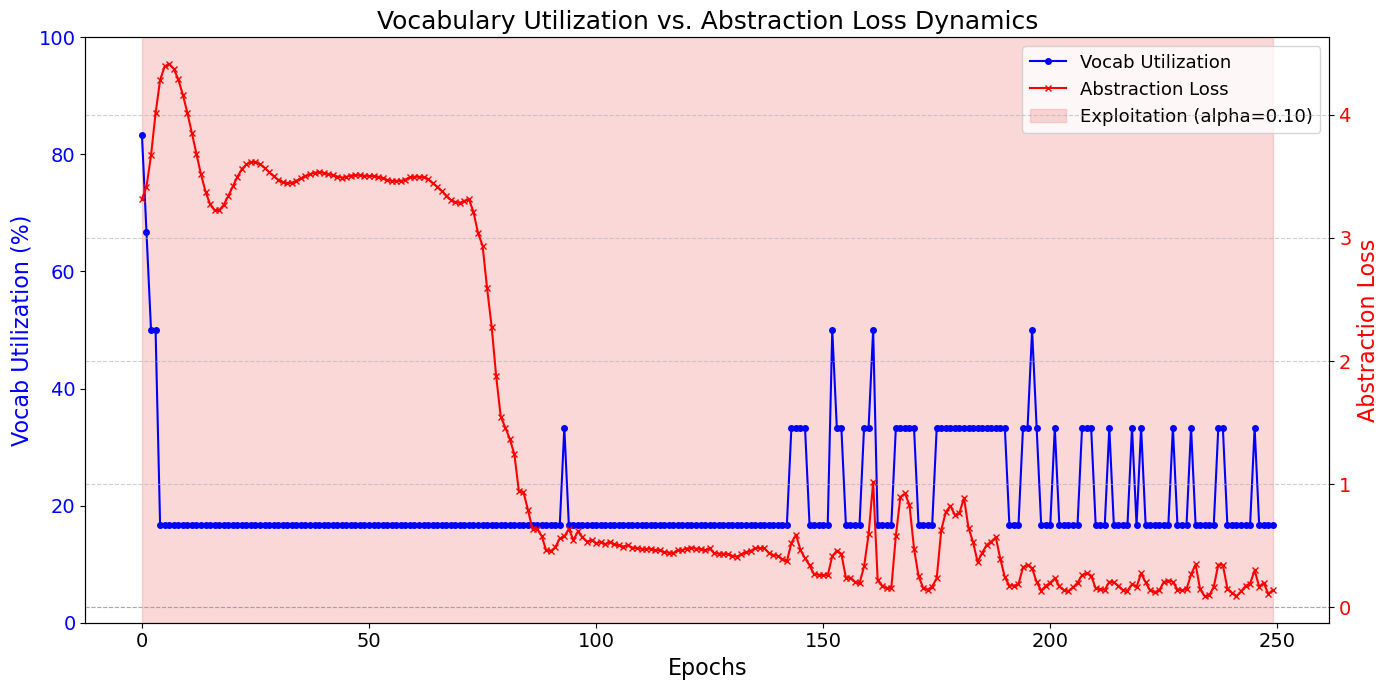

In [ ]:
from sorl.stat import * 
plot_vocab_abs_dynamics(record)
plot_training_metrics_combined(record)

(d). SGPO with distillation settings

In [ ]:
from sorl.neo_utils import sorl_search_v3, compute_sgpo_loss, sorl_evaluate, compute_vocab_utilization_rate, compute_loss
from sorl.gapt import GatedPhaseTransition
import copy
from collections import defaultdict

# ============= Models =============
# Parent: Already trained, frozen forever
model.eval()
model.requires_grad_(False)  # Save memory

# Child: Random initialization
child_model = copy.deepcopy(model) # Init from parent
child_model.requires_grad_(True)
child_model.train()  # Ensure training mode (parent was in .eval())

# ------ SGPO for emerging abstraction structure -------
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)

batch_size = 16
memory_span = 2 * seq_len + 2
attn_blocksize = 1792
alpha_loss = 0.1
n = 2
min_temperature = 0.0
max_temperature = 5
temperatures = torch.tensor([min_temperature, max_temperature], device=model.device)
n_eval = 4 
temperatures_eval = torch.tensor([min_temperature, max_temperature, max_temperature, max_temperature], device=model.device)
K = 4
max_iterations = 2
num_steps = 500
gapt = GatedPhaseTransition()

record = defaultdict(list)
vocab_util = 1.0
for step in range(num_steps): 

    memory_span = 1792
 
    optimizer.zero_grad()

    tokens, _ = loader.get_batch(batch_size)

    # --- mixture of SoRL selection & deep supervision (avg. loss per iteration) ---
    with torch.no_grad(): 
        search_tokens, search_ppt, search_adv = sorl_search_v3(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures,
                                                               truncate_seq_len=False)
    # --- compute loss ---
    traj_loss, grpo_loss = compute_sgpo_loss(search_tokens, search_adv, child_model, memory_span, attn_blocksize)    
                                       
    # loss = gapt.step(traj_loss, alpha_loss * abs_loss, verbose=True)
    loss = traj_loss + alpha_loss * grpo_loss

    # --- optimize --- 
    loss.backward() 
    optimizer.step()

    if step % 2 == 0: 
        with torch.no_grad(): 
            temperatures_eval = torch.tensor([0.0, max_temperature, max_temperature, max_temperature], device=model.device)
            val_tokens, val_adv, traj_loss, abs_loss = sorl_evaluate(tokens, child_model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                     truncate_seq_len=False)
            vocab_util = compute_vocab_utilization_rate(val_tokens, child_model)
            record['vocab_util'].append(vocab_util * 100)
            record['search_adv'].append(val_adv.item() * 100)
            record['abs_loss'].append(abs_loss.item())
            record['alpha_loss'].append(alpha_loss)
        print(f"validation step {step} | traj_loss: {traj_loss.item():.2f} | abs_loss: {abs_loss.item():.2f} | search adv: {val_adv.item() * 100:.2f}% | vocab util: {vocab_util * 100:.2f}% | alpha_loss: {alpha_loss:.2f}")

\paragraph{Hybrid SoRL--SGPO sampling.}
Given an input sequence $s$, we draw $K$ abstraction candidates
\[
a_1,\dots,a_K \sim p_\theta(a \mid s;\alpha).
\]

For each $i \in \{1,\dots,K\}$ we compute
\begin{align}
u_i      &= R(s,a_i) &&\text{(utility / reward)} \\
\ell_i   &= \log p_\theta(s \mid a_i) &&\text{(reconstruction log-likelihood)}.
\end{align}

We define SGPO-style exploration scores via the negative $z$-score of
$\ell_i$:
\begin{align}
\mu_\ell &= \frac{1}{K}\sum_{i=1}^K \ell_i, \\
\sigma_\ell &= \sqrt{\frac{1}{K}\sum_{i=1}^K (\ell_i - \mu_\ell)^2}, \\
z_i &= - \frac{\ell_i - \mu_\ell}{\sigma_\ell + \varepsilon},
\end{align}
where $\varepsilon > 0$ is a small constant.

We then construct \emph{hybrid} logits
$$
h_i = \beta \, u_i + \lambda \, z_i,
$$
with exploitation scale $\beta \ge 0$ and exploration scale $\lambda \ge 0$,
and define a SGPO-reweighted distribution over rollouts
$$
p_{\text{hyb}}(i \mid s, a_{1:K})
= \frac{\exp(h_i)}{\sum_{k=1}^K \exp(h_k)}.
$$

The greedy SoRL index is
$$
i^\star = \arg\max_{i} u_i.
$$

We select a single rollout index $j$ from a mixture of greedy and
SGPO-biased sampling:
$$
q_\varepsilon(j \mid s, a_{1:K})
= (1-\varepsilon)\,\delta_{j,i^\star}
  + \varepsilon\, p_{\text{hyb}}(j \mid s, a_{1:K}),
$$
where $\varepsilon \in [0,1]$ and $\delta_{j,i^\star}$ is the Kronecker delta.

Given the chosen abstraction $a_j$, we apply the standard single-choice
SoRL loss $L_{\text{SoRL}}$:
$$
\mathcal{L}(\theta)
= \mathbb{E}_{s}
  \,\mathbb{E}_{a_{1:K} \sim p_\theta(\cdot \mid s;\alpha)}
  \,\mathbb{E}_{j \sim q_\varepsilon(\cdot \mid s, a_{1:K})}
  \big[\, L_{\text{SoRL}}(s, a_j, u_j; \alpha) \,\big].
$$

(e). Offline Distillation

In [8]:
from sorl.neo_utils import sorl_search_v2, compute_loss, sorl_evaluate
# from sorl.neo_utils import sorl_search, sorl_evaluate_v2
from sorl.gapt import GatedPhaseTransition
import torch, copy
from collections import defaultdict


# ============= Models =============
# Parent: Already trained, frozen forever
model.eval()
model.requires_grad_(False)  # Save memory

# Child: Random initialization
# child_model = GAT(gat_config)  # Fresh random weights
child_model = copy.deepcopy(model) # Init from parent
child_model.requires_grad_(True)
child_model.train()  # Ensure training mode (parent was in .eval())

optimizer = torch.optim.AdamW(child_model.parameters(), lr=1e-3, weight_decay=0.1)

# ============= Hyperparameters =============
batch_size = 16
memory_span = 1792
attn_blocksize = 1792
alpha_loss = 0.1  # Fixed (not adaptive, since child starts from scratch)
alpha_sel = 0.0
sel_mode = "abs_ppt"
n = 1
min_temperature = 0.0
max_temperature = 5
# temperatures = torch.tensor([min_temperature, min_temperature], device=model.device)
temperatures = torch.tensor([min_temperature], device=model.device)


# Evaluation settings
n_eval = 4
temperatures_eval = torch.tensor([min_temperature, max_temperature, 
                                   max_temperature, max_temperature])
K = 4
max_iterations = 2
num_steps = 500
record = defaultdict(list)

# ============= Training Loop =============
for step in range(num_steps):
    optimizer.zero_grad()
    tokens, _ = loader.get_batch(batch_size)
    
    # === PARENT: Generate training rollouts (frozen) ===
    with torch.no_grad():
        parent_rollouts, parent_ppt, parent_search_adv = sorl_search_v2(
            tokens, 
            model, # use model for 'offline distillation', child_model for 'online distillation'
            n=n, K=K, 
            max_iterations=max_iterations,
            memory_span=memory_span,
            attn_blocksize=attn_blocksize,
            temperature=temperatures,
            truncate_seq_len=False,
            alpha_select=alpha_sel,
            select_mode=sel_mode
        )
    
    # === CHILD: Learn from parent's rollouts ===
    traj_loss, abs_loss = compute_loss(
        parent_rollouts, child_model,
        memory_span=memory_span,
        attn_blocksize=attn_blocksize
    )
    loss = traj_loss + alpha_loss * abs_loss
    loss.backward()
    optimizer.step()
    
    # === EVALUATION: Test child's own capabilities ===
    if step % 10 == 0:
        with torch.no_grad():
            # Child does its own search
            child_rollouts, child_search_adv, child_traj_loss, child_abs_loss = sorl_evaluate(
                tokens, child_model,
                n=n_eval, K=K,
                max_iterations=max_iterations,
                memory_span=memory_span,
                attn_blocksize=attn_blocksize,
                temperature=temperatures_eval,
                truncate_seq_len=False
            )
            child_vocab_util = compute_vocab_utilization_rate(child_rollouts, child_model)
        
        print(f"\n{'='*60}")
        print(f"[Step {step}/{num_steps}]")
        print(f"Training (from parent rollouts):")
        print(f"  ├─ traj_loss: {traj_loss.item():.3f}")
        print(f"  ├─ abs_loss: {abs_loss.item():.3f}")
        print(f"  └─ parent search_adv: {parent_search_adv.item() * 100:.1f}%")
        print(f"\nChild's Own Performance:")
        print(f"  ├─ search_adv: {child_search_adv.item() * 100:.1f}%  ← KEY METRIC")
        print(f"  ├─ vocab_util: {child_vocab_util * 100:.1f}%        ← KEY METRIC")
        print(f"  ├─ traj_loss: {child_traj_loss.item():.3f}")
        print(f"  └─ abs_loss: {child_abs_loss.item():.3f}")

        record['traj_loss'].append(child_traj_loss.item())
        record['abs_loss'].append(child_abs_loss.item())
        record['search_adv'].append(child_search_adv.item() * 100)
        record['vocab_util'].append(child_vocab_util * 100)
    
    # Compact progress during training
    if step % 10 != 0:
        print(f"Step {step}: loss={loss.item():.3f}", end="\r")

# ============= Final Comparison =============
print(f"\n{'='*60}")
print("FINAL RESULTS:")
print(f"\nParent (baseline):")
temperatures_eval = torch.tensor([0.0, max_temperature, 
                                   max_temperature, max_temperature])
with torch.no_grad():
    tokens, _ = loader.get_batch(batch_size * 4)  # Larger eval batch
    parent_eval, parent_adv, _, _ = sorl_evaluate(tokens, model, n=n_eval, K=K, 
                                                   max_iterations=max_iterations,
                                                   memory_span=memory_span,
                                                   attn_blocksize=attn_blocksize,
                                                   temperature=temperatures_eval)
    parent_util = compute_vocab_utilization_rate(parent_eval, model)

print(f"  search_adv: {parent_adv.item() * 100:.1f}%")
print(f"  vocab_util: {parent_util * 100:.1f}%")

print(f"\nChild (distilled):")
with torch.no_grad():
    child_eval, child_adv, _, _ = sorl_evaluate(tokens, child_model, n=n_eval, K=K,
                                                 max_iterations=max_iterations,
                                                 memory_span=memory_span,
                                                 attn_blocksize=attn_blocksize,
                                                 temperature=temperatures_eval)
    child_util = compute_vocab_utilization_rate(child_eval, child_model)

print(f"  search_adv: {child_adv.item() * 100:.1f}%")
print(f"  vocab_util: {child_util * 100:.1f}%")

print(f"\nImprovement:")
print(f"  Δ search_adv: {(child_adv - parent_adv).item() * 100:+.1f}%")
print(f"  Δ vocab_util: {(child_util - parent_util) * 100:+.1f}%")


[Step 0/500]
Training (from parent rollouts):
  ├─ traj_loss: 1.126
  ├─ abs_loss: 7.995
  └─ parent search_adv: 0.0%

Child's Own Performance:
  ├─ search_adv: -0.8%  ← KEY METRIC
  ├─ vocab_util: 66.7%        ← KEY METRIC
  ├─ traj_loss: 1.118
  └─ abs_loss: 7.317
Step 9: loss=1.606
[Step 10/500]
Training (from parent rollouts):
  ├─ traj_loss: 1.147
  ├─ abs_loss: 4.373
  └─ parent search_adv: 0.0%

Child's Own Performance:
  ├─ search_adv: -2.4%  ← KEY METRIC
  ├─ vocab_util: 50.0%        ← KEY METRIC
  ├─ traj_loss: 1.138
  └─ abs_loss: 3.900
Step 19: loss=1.451
[Step 20/500]
Training (from parent rollouts):
  ├─ traj_loss: 1.143
  ├─ abs_loss: 2.973
  └─ parent search_adv: 0.0%

Child's Own Performance:
  ├─ search_adv: -1.6%  ← KEY METRIC
  ├─ vocab_util: 33.3%        ← KEY METRIC
  ├─ traj_loss: 1.144
  └─ abs_loss: 2.639
Step 29: loss=1.362
[Step 30/500]
Training (from parent rollouts):
  ├─ traj_loss: 1.167
  ├─ abs_loss: 1.962
  └─ parent search_adv: 0.0%

Child's Own Perfo

1. (Base) search adv -0.9% | vocab util 83.3%
2. (Online distillation): search adv 1.2% | vocab util 33.0%
3. (Offline distillation): search adv: 2.6% | vocab util: 83%

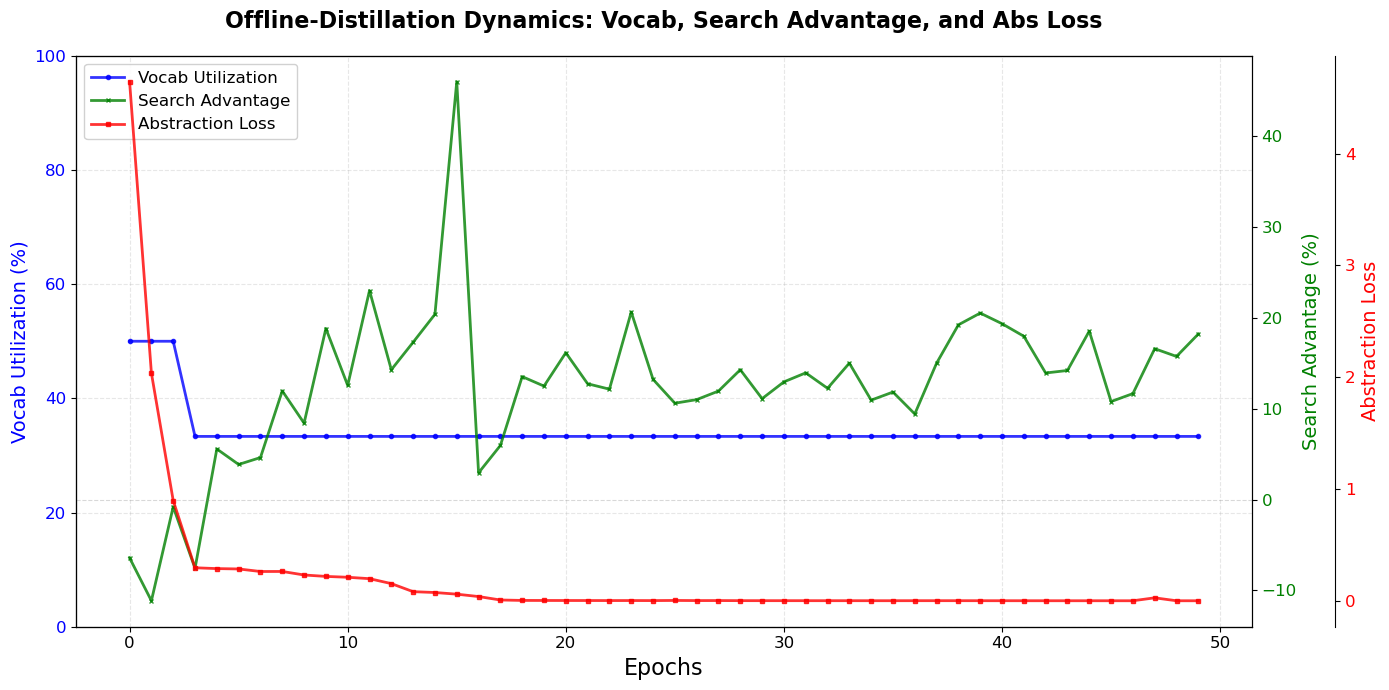

In [ ]:
from sorl.stat import * 

plot_training_metrics_combined(record)

In [ ]:
# Idea 1. 
# EMA model rollout --> online model learns (alpha=0.1) with SGPO loss
# potentially unifies 'offline distillation' with 'exploration with SGPO'??

In [6]:
# generate function implementation 
# ----------------------------------
from sorl.neo_utils import generate

tokens, loss_mask = loader.get_batch(1)
idx = tokens[:, :1 + seq_len].clone()
print(f"init   | idx: {idx[0].tolist()}")
for i in range(seq_len): 
    idx = generate(model, idx, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=1792, temperature=torch.tensor(min_temperature))
    idx_without_abstraction = idx[idx < model.vocab_sizes[0]]
    print(f"step {i+1} idx (abstraction free): {idx_without_abstraction.tolist()}")
    print(f"                         idx : {idx[0].tolist()}")

correct_cp = torch.allclose(idx_without_abstraction[1 : 1 + seq_len], idx_without_abstraction[1 + seq_len : 2 + 2*seq_len])
print(f"Copy correct: {correct_cp}")

init   | idx: [20, 0, 0, 5, 4, 6, 2, 9, 6, 4, 3, 9, 0, 8, 6, 7, 2]
step 1 idx (abstraction free): [20, 0, 0, 5, 4, 6, 2, 9, 6, 4, 3, 9, 0, 8, 6, 7, 2, 0]
                         idx : [20, 0, 0, 5, 4, 26, 6, 2, 9, 6, 26, 4, 3, 9, 0, 26, 8, 6, 7, 2, 26, 0]
step 2 idx (abstraction free): [20, 0, 0, 5, 4, 6, 2, 9, 6, 4, 3, 9, 0, 8, 6, 7, 2, 0, 0]
                         idx : [20, 0, 0, 5, 4, 26, 6, 2, 9, 6, 26, 4, 3, 9, 0, 26, 8, 6, 7, 2, 26, 0, 0]
step 3 idx (abstraction free): [20, 0, 0, 5, 4, 6, 2, 9, 6, 4, 3, 9, 0, 8, 6, 7, 2, 0, 0, 0]
                         idx : [20, 0, 0, 5, 4, 26, 6, 2, 9, 6, 26, 4, 3, 9, 0, 26, 8, 6, 7, 2, 26, 0, 0, 0]
step 4 idx (abstraction free): [20, 0, 0, 5, 4, 6, 2, 9, 6, 4, 3, 9, 0, 8, 6, 7, 2, 0, 0, 0, 4]
                         idx : [20, 0, 0, 5, 4, 26, 6, 2, 9, 6, 26, 4, 3, 9, 0, 26, 8, 6, 7, 2, 26, 0, 0, 0, 4]
step 5 idx (abstraction free): [20, 0, 0, 5, 4, 6, 2, 9, 6, 4, 3, 9, 0, 8, 6, 7, 2, 0, 0, 0, 4, 6]
                         idx : [20, 0,

In [21]:
from sorl.eval import compute_vocab_utilization_rate

def eval_cp(model, tokens, K, max_iterations, memory_span, seq_len, loader, temperature=torch.tensor(0.5), num_samples=100):
    n_correct = 0
    abs_idx = []
    for _ in range(num_samples): 
        tokens, loss_mask = loader.get_batch(1)
        idx = tokens[:, :1 + seq_len].clone()
        for i in range(seq_len): 
            idx = generate(model, idx, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=1792, temperature=temperature)
            idx_without_abstraction = idx[idx < model.vocab_sizes[0]]
            abs_idx.append(idx[idx >= model.vocab_sizes[0]])
        correct_cp = torch.allclose(idx_without_abstraction[1 : 1 + seq_len], idx_without_abstraction[1 + seq_len : 2 + 2*seq_len])
        n_correct += correct_cp
    acc = n_correct / num_samples
    print(f"=== Copy & Paste Evaluation ===\n Copy correct: {acc * 100:.2f}%")

    data = torch.cat(abs_idx, dim=0)
    abs_util_rate = compute_vocab_utilization_rate(data, model)
    return acc, abs_util_rate


eval_cp(model, tokens, K, max_iterations, memory_span, seq_len, loader, num_samples=20)

=== Copy & Paste Evaluation ===
 Copy correct: 100.00%


(1.0, 0.8333333333333334)

 Total abs tokens: 6 | Unique abs tokens: 1 | Abs util rate: 16.67%


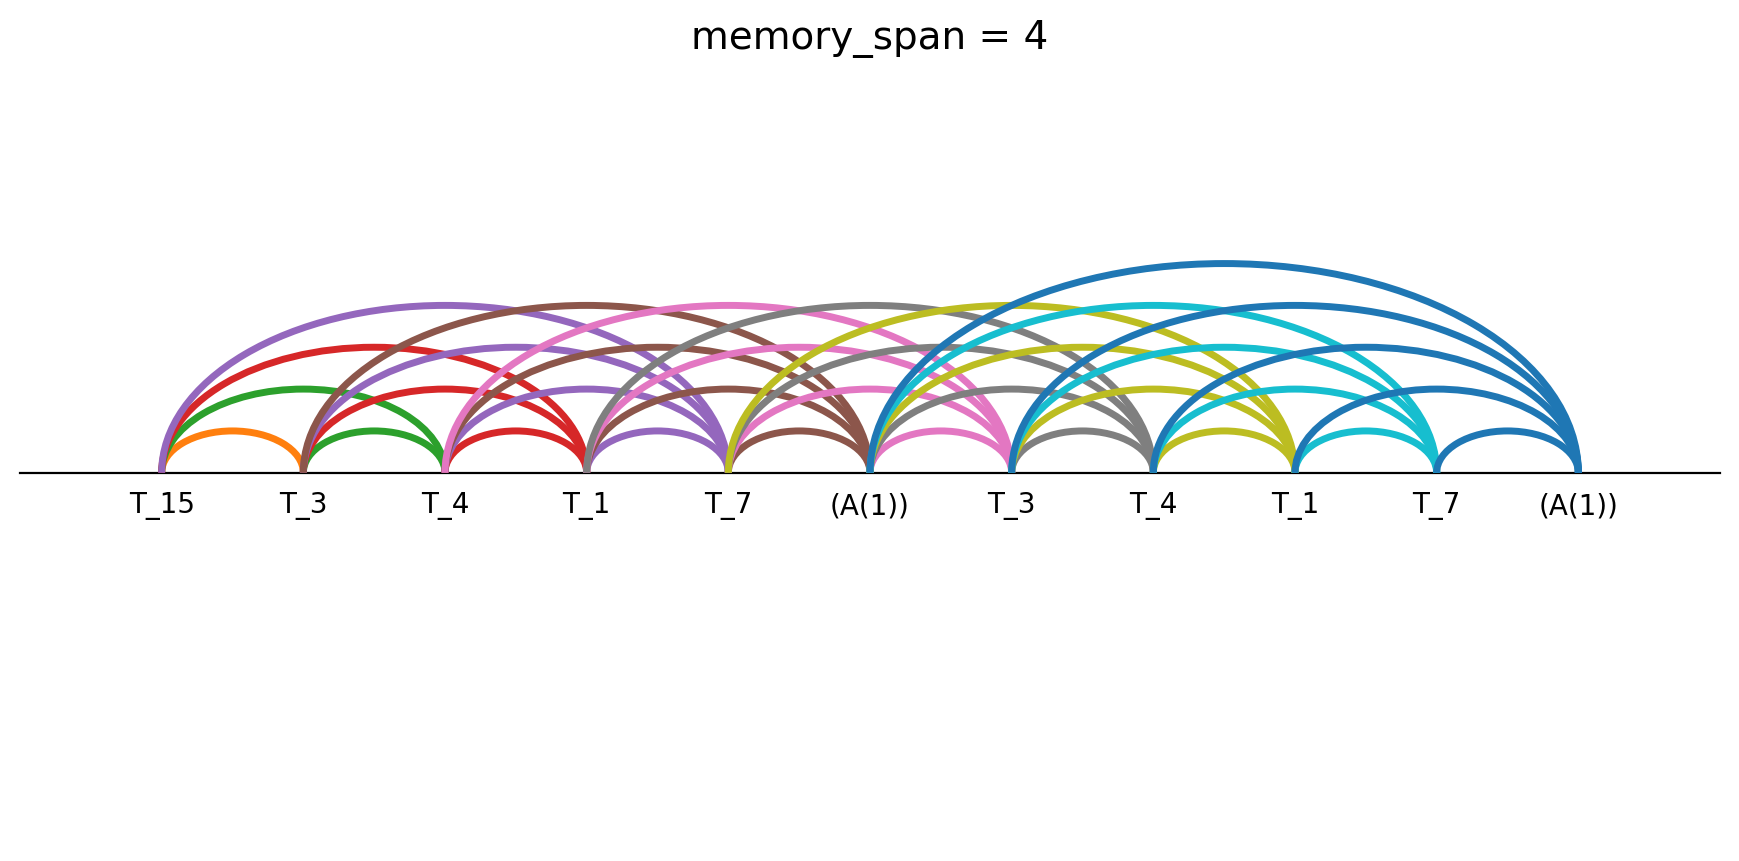

In [6]:
# Simple 2D Attention Mask (without num_heads dimension)
# ======================================================

import torch
from sorl.stat import plot_attn_arcs, materialize_attention_mask, AttentionMaskVisualizer

# Your existing variables
tokens, loss_mask = loader.get_batch(1)
with torch.no_grad(): 
    search_tokens, search_ppt, search_adv = sorl_search(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperature,
                                                            truncate_seq_len=False)

# Generate 2D attention mask
levels = (search_tokens >= model.vocab_sizes[0]).long()
attn_mask = materialize_attention_mask(search_tokens, model, memory_span, attn_blocksize=1792)
visualizer = AttentionMaskVisualizer(search_tokens, model, attn_mask)

visualizer.plot_arcs(title=f"memory_span = {memory_span}")


In [ ]:
# heuristic rollout
import os, glob, itertools
from pathlib import Path

# MPS specific data loader functional (single device ver.)
# --------------------------------------------
def _load_data_shard(file: Path):
    header = torch.from_file(str(file), False, 256, dtype=torch.int32) # header is 256 int32
    assert header[0] == 20240520, "magic number mismatch in the data .bin file"
    assert header[1] == 1, "unsupported version"
    num_tokens = int(header[2]) # number of tokens (claimed)
    with file.open("rb", buffering=0) as f:
        tokens = torch.empty(num_tokens, dtype=torch.uint16, pin_memory=False) # MPS requires pin_memory=False
        f.seek(256 * 4)
        nbytes = f.readinto(tokens.numpy()) # avoid bytes->array copy by @YouJiacheng
        assert nbytes == 2 * num_tokens, "number of tokens read does not match header"
    return tokens

def data_generator(filename_pattern: str, sequence_length: int, device: str): 

    filename_pattern = "data/fineweb10B/fineweb_train_*.bin"
    files = [Path(file) for file in sorted(glob.glob(filename_pattern))]
    file_iter = itertools.cycle(files)
    tokens, pos = _load_data_shard(next(file_iter)), 0
    while True: 
        # Concern 1. Doesn't this means end-of-file is never reached?
        if pos + sequence_length + 1 >= len(tokens): # not enough data left -> load a new file
            tokens, pos = _load_data_shard(next(file_iter)), 0

        idx = tokens[pos : pos + sequence_length + 1].unsqueeze(0).to(device=device, dtype=torch.int32, non_blocking=True)
        pos += sequence_length
        yield idx


data = _load_data_shard(Path("data/fineweb10B/fineweb_train_000002.bin"))

train_loader = data_generator(filename_pattern="data/fineweb10B/fineweb_train_*.bin", sequence_length=256, device="cpu")
val_loader = data_generator(filename_pattern="data/fineweb10B/fineweb_val_000000.bin", sequence_length=256, device="cpu")

In [ ]:
from sorl.neo_utils import sorl_search_v2 

n = 2
K = 8
max_iterations=2
memory_span=1792
attn_blocksize=1792
temperature=10.0 

tokens = next(train_loader)

with torch.no_grad(): 
    search_tokens, search_ppt, search_adv, pt_curiosity = sorl_search_v2(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperature)

In [ ]:
# --- Benchmark Speed & Memory Cost --- 
from sorl.benchmark import run_benchmark_suite
import torch 


# Prepare data - TEST WITH SMALLER SEQUENCE FIRST
tokens = next(train_loader)

# Run benchmark
results = run_benchmark_suite(
    model, 
    tokens, 
    memory_span=1024, 
    num_runs=10
)